# Libraries


In [ ]:
#!pip install "rembg[cpu]"

In [ ]:
import torch
import torchvision.transforms as T
import torchvision
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import mean_absolute_error
from rembg import remove
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import google.colab
google.colab.drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.applications import (
    VGG19,
    ResNet50,
    DenseNet121
)

from tensorflow.keras.applications import (
    vgg19,
    resnet50,
    densenet
)

# Path

In [ ]:
path_main = "" #directory of the data
path_test= path_main + "" # real image to test
test_measurements="" # measurements of the person in the real image
path_model= path_main + "" #path model trained

# Load and Preprocessing IMG

The repository intel-isl_MiDaS does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
The repository rwightman_gen-efficientnet-pytorch does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:02<00:00, 39.6MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

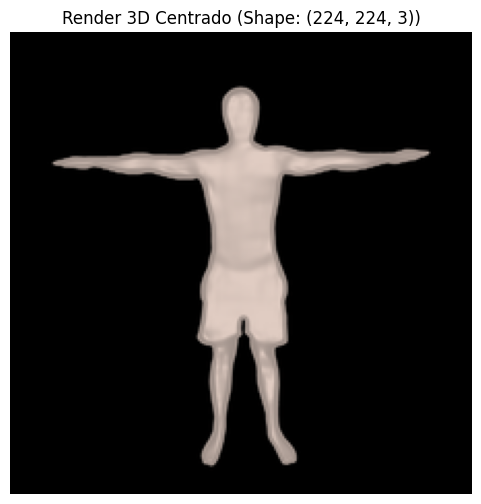

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from rembg import remove, new_session
from PIL import Image
from io import BytesIO
from tensorflow.keras.applications.resnet50 import preprocess_input

# ==========================================
# 1. LOAD MODELS
# ==========================================
# Load the depth estimation and human segmentation models.
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

rembg_session = new_session("u2net_human_seg")

# ==========================================
# 2. GENERATE THE FOREGROUND MASK
# ==========================================
# Remove the background and extract a binary mask from the alpha channel.
image_path = path_test + "/tincho-1.jpg"

with open(image_path, "rb") as f:
    result_rembg = remove(f.read(), session=rembg_session)

img_rgba = Image.open(BytesIO(result_rembg)).convert("RGBA")
alpha = np.array(img_rgba.getchannel("A"))

mask = np.where(alpha > 200, 1.0, 0.0).astype(np.float32)

# ==========================================
# 3. ESTIMATE DEPTH
# ==========================================
# Predict a dense depth map using MiDaS.
img_cv = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
input_batch = midas_transforms(img_rgb)

with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth = prediction.cpu().numpy()

# ==========================================
# 4. CREATE A SMOOTH 3D-LIKE RENDER
# ==========================================
# Normalize depth values only inside the segmented body.
depth_norm = np.zeros_like(depth)

mask_bool = mask > 0

if np.any(mask_bool):
    depth_min = depth[mask_bool].min()
    depth_max = depth[mask_bool].max()

    depth_norm[mask_bool] = (
        depth[mask_bool] - depth_min
    ) / (depth_max - depth_min + 1e-8)

# Smooth the depth map to avoid sharp surface transitions.
depth_smooth = cv2.bilateralFilter(
    depth_norm.astype(np.float32),
    d=15,
    sigmaColor=0.1,
    sigmaSpace=15,
)

depth_smooth = cv2.GaussianBlur(depth_smooth, (61, 61), 0)

# Estimate surface normals from the depth gradients.
dzdx = cv2.Sobel(depth_smooth, cv2.CV_64F, 1, 0, ksize=7)
dzdy = cv2.Sobel(depth_smooth, cv2.CV_64F, 0, 1, ksize=7)

relief_strength = 1.0

normals = np.dstack(
    (
        -dzdx * relief_strength,
        -dzdy * relief_strength,
        np.ones_like(depth_smooth),
    )
)

norm = np.linalg.norm(normals, axis=2, keepdims=True)
unit_normals = normals / (norm + 1e-8)

# Use frontal lighting to produce a uniform appearance.
light_vector = np.array([0.0, 0.0, 1.0])
light_vector /= np.linalg.norm(light_vector)

shading = np.sum(unit_normals * light_vector, axis=2)
shading = np.clip(shading, 0, 1)

skin_color = np.array([225, 205, 195], dtype=np.float32)

# A strong ambient component reduces shading artifacts.
ambient_light = 0.70

render_rgb = skin_color * (
    shading[:, :, np.newaxis] * (1.0 - ambient_light)
    + ambient_light
)

render_rgb[mask == 0] = [0, 0, 0]

render_final = np.clip(render_rgb, 0, 255).astype(np.uint8)

# ==========================================
# 5. CENTER THE SUBJECT FOR THE CNN INPUT
# ==========================================
# Crop around the segmented body and resize while preserving aspect ratio.
ys, xs = np.where(mask > 0)

padding = 225

height, width = mask.shape

x_min = max(0, xs.min() - padding)
y_min = max(0, ys.min() - padding)
x_max = min(width, xs.max() + padding)
y_max = min(height, ys.max() + padding)

render_cropped = render_final[
    int(y_min):int(y_max),
    int(x_min):int(x_max),
]

target_size = 224

render_pil = Image.fromarray(render_cropped)

w, h = render_pil.size
scale = target_size / max(w, h)

new_w = int(w * scale)
new_h = int(h * scale)

render_resized = render_pil.resize(
    (new_w, new_h),
    Image.LANCZOS,
)

# Place the resized body at the center of a square canvas.
canvas = Image.new(
    "RGB",
    (target_size, target_size),
    (0, 0, 0),
)

offset_x = (target_size - new_w) // 2
offset_y = (target_size - new_h) // 2

canvas.paste(render_resized, (offset_x, offset_y))

img_np = np.array(canvas)

# Display the final render.
plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f"Centered 3D Render (Shape: {img_np.shape})")
plt.axis("off")
plt.show()

# ==========================================
# 6. PREPARE THE INPUT FOR RESNET50
# ==========================================
img_model = np.expand_dims(img_np, axis=0).astype(np.float32)
img_model = preprocess_input(img_model)

# Model

In [ ]:
model = tf.keras.models.load_model(path_model)
model.summary()

Model: "ResNet50_regressor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,152 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,768 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ measurements        │ (None, 8)         │      1,032 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,287,898 (229.98 MB)

 Trainable params: 17,217,288 (65.68 MB)

 Non-trainable params: 8,636,032 (32.94 MB)

 Optimizer params: 34,434,578 (131.36 MB)

In [ ]:
# prediction normalized
pred = model.predict(img_model)

# normalization used in training
mean={'waist_circ': np.float32(88.364105),
 'pelvis_circ': np.float32(105.011055),
 'arm_span': np.float32(175.36346),
 'chest_circ': np.float32(99.36541),
 'arm_length': np.float32(51.11138),
 'shoulders_width': np.float32(35.87447),
 'torso_length': np.float32(50.89531),
 'leg_length': np.float32(78.06813)}

std= {'waist_circ': np.float32(12.94832),
 'pelvis_circ': np.float32(8.5310135),
 'arm_span': np.float32(11.358396),
 'chest_circ': np.float32(10.323789),
 'arm_length': np.float32(3.2731361),
 'shoulders_width': np.float32(3.7896547),
 'torso_length': np.float32(3.2771742),
 'leg_length': np.float32(5.015908)}


# measurements considered
feature_order = [
    'waist_circ', 'pelvis_circ', 'arm_span', 'chest_circ',
    'arm_length', 'shoulders_width', 'torso_length', 'leg_length'
]

mean_np = np.array([mean[k] for k in feature_order], dtype=np.float32)
std_np  = np.array([std[k] for k in feature_order], dtype=np.float32)

# prediction without normalization in CM
pred = pred * std_np + mean_np

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
#MAE in CM of the real image and prediction

df_test=pd.read_csv(test_measurements) #testing dataset

y_true = df_test.iloc[0][1:].values.astype(float)
y_pred = pred.flatten()

mae_per_feature = np.abs(y_true - y_pred)

for col, err in zip(df_test.columns[1:], mae_per_feature):
    print(f"{col}: {err:.2f}")

print("TRUE: ",y_true)
print("PRED: ",y_pred)

waist_circ: 0.24
pelvis_circ: 11.85
arm_span: 2.56
chest_circ: 3.60
arm_length: 1.37
shoulders_width: 2.91
torso_length: 5.22
leg_length: 2.28
TRUE:  [ 85.  93. 167. 100.  51.  37.  55.  79.]
PRED:  [ 84.76103  104.84741  169.55598   96.402435  49.625443  34.09141
  49.784714  76.71517 ]


# GradCam

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name, pred_index=0):
    # 1. Find the backbone dynamically
    backbone = next(layer for layer in model.layers if isinstance(layer, tf.keras.Model))

    # 2. Model: From the image to the activations and backbone output
    grad_backbone = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=[backbone.get_layer(last_conv_layer_name).output, backbone.output]
    )

    # 3. Extract the "Head" layers based on the exact topology
    layers = model.layers
    avg_pool = next(l for l in layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D))
    max_pool = next(l for l in layers if isinstance(l, tf.keras.layers.GlobalMaxPooling2D))
    concat = next(l for l in layers if isinstance(l, tf.keras.layers.Concatenate))

    # Save the concatenate index to iterate over the rest of the Dense layers
    idx_concat = layers.index(concat)
    head_dense_layers = layers[idx_concat + 1:]

    # 4. MANUALLY record the mathematical flow to avoid the Keras error
    with tf.GradientTape() as tape:
        # Extract the feature map and the raw ResNet output
        conv_outputs, bb_out = grad_backbone(img_tensor)

        # Watch the activations
        tape.watch(conv_outputs)

        # -- FORWARD PASS RECONSTRUCTION --
        # Replicate the parallel branches
        x_avg = avg_pool(bb_out)
        x_max = max_pool(bb_out)

        # Merge them
        x = concat([x_avg, x_max])

        # Pass through all remaining layers (Dense, BatchNorm, Dropout)
        for layer in head_dense_layers:
            x = layer(x)

        preds = x

        # Select the prediction for the target metric
        target_output = preds[:, pred_index]

    # 5. Gradient calculation (Now they are 100% connected!)
    grads = tape.gradient(target_output, conv_outputs)

    if grads is None:
        raise ValueError("The gradient is None. Check the connections.")

    # 6. Global Average Pooling and normalization
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU and normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def superimpose_heatmap(img_rgb, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed_img = heatmap_rgb * alpha + img_rgb
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img

def plot_gradcam_diagnostics(model, img_rgb, img_tensor, measurements=None, target_layer="conv5_block3_out"):
    if measurements is None:
        measurements = ["waist", "pelvis", "arm_span", "chest", "arm_len", "shoulders", "torso", "inner_leg"]

    fig = plt.figure(figsize=(24, 10))

    # 1. Creamos la grilla de 2 filas y 10 columnas
    gs = GridSpec(2, 10, figure=fig)
    axes = []

    # 2. Fila superior: 5 imágenes (ocupan 2 columnas cada una: 0-2, 2-4, 4-6, 6-8, 8-10)
    for i in range(5):
        ax = fig.add_subplot(gs[0, i*2 : (i+1)*2])
        axes.append(ax)

    # 3. Fila inferior: 4 imágenes (ocupan 2 columnas, arrancando desde la columna 1)
    for i in range(4):
        ax = fig.add_subplot(gs[1, i*2 + 1 : i*2 + 3])
        axes.append(ax)

    # El resto del código queda exactamente igual, ya que 'axes' es una lista de 9 elementos
    axes[0].imshow(img_rgb)
    axes[0].set_title("Preprocessed Real \n Test Image", fontsize=28, fontweight='bold')
    axes[0].axis('off')

    for i, measure_name in enumerate(measurements):
        heatmap = make_gradcam_heatmap(img_tensor, model, target_layer, pred_index=i)
        blended_img = superimpose_heatmap(img_rgb, heatmap)

        axes[i+1].imshow(blended_img)
        axes[i+1].set_title(f"Attention: {measure_name}", fontsize=28, fontweight='bold')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

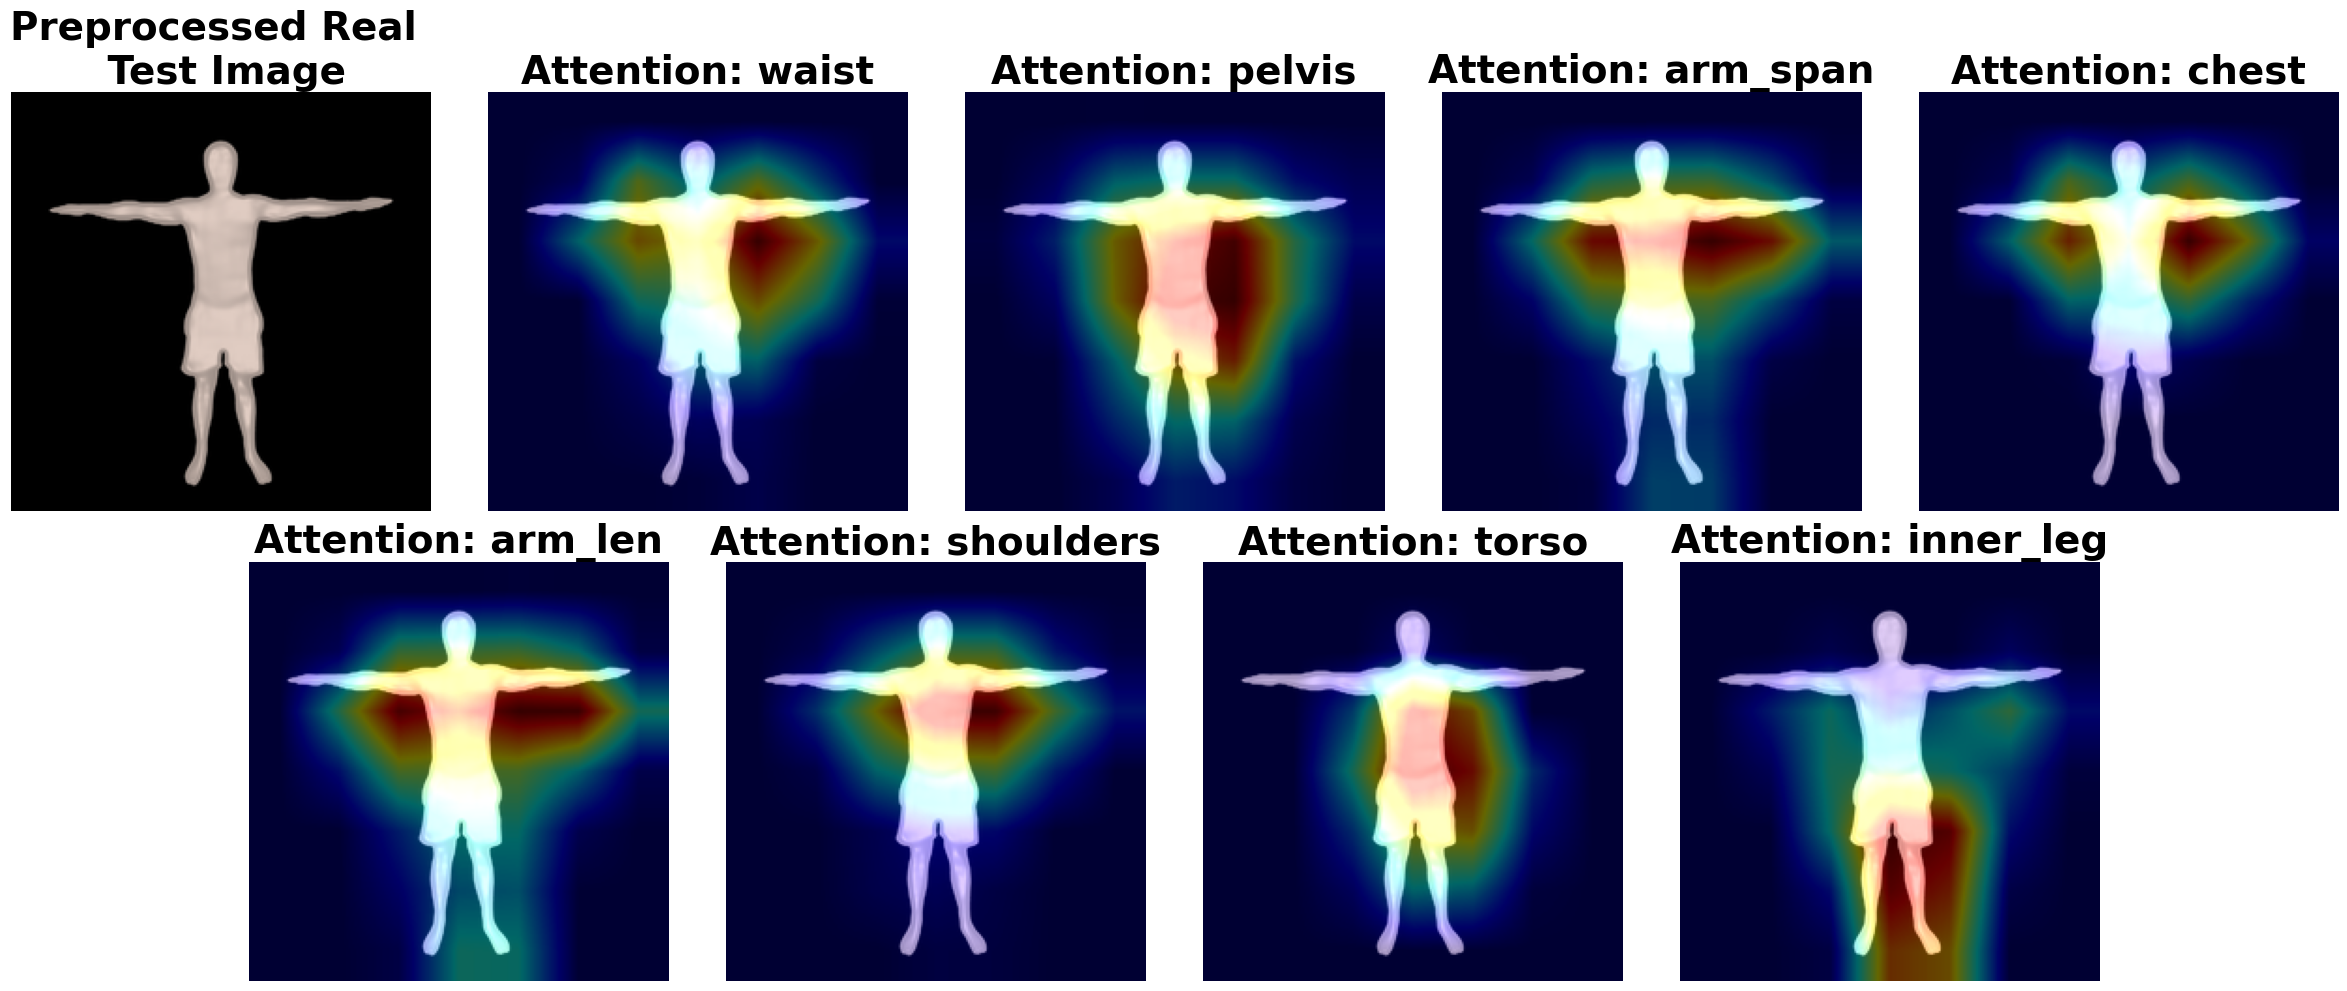

In [ ]:
plot_gradcam_diagnostics(
    model=model,
    img_rgb=img_np,
    img_tensor=img_model,
    target_layer="conv5_block3_out"
)